In [1]:
import pandas as pd
from experiment_utils import save_result
import numpy as np

In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data.drop(columns='Unnamed: 0', inplace=True)
data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'year', 'is_world_cup',
       'is_qualifier', 'match_id', 'home_rank_date_used', 'home_rank',
       'home_previous_rank', 'home_rank_change', 'home_total_points',
       'home_previous_points', 'away_rank_date_used', 'away_rank',
       'away_previous_rank', 'away_rank_change', 'away_total_points',
       'away_previous_points', 'rank_advantage', 'points_diff', 'home_elo',
       'away_elo', 'elo_advantage', 'result'],
      dtype='str')

In [3]:
data.columns

Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'neutral', 'year', 'is_world_cup',
       'is_qualifier', 'match_id', 'home_rank_date_used', 'home_rank',
       'home_previous_rank', 'home_rank_change', 'home_total_points',
       'home_previous_points', 'away_rank_date_used', 'away_rank',
       'away_previous_rank', 'away_rank_change', 'away_total_points',
       'away_previous_points', 'rank_advantage', 'points_diff', 'home_elo',
       'away_elo', 'elo_advantage', 'result'],
      dtype='str')

In [4]:
feature_colums = data[['home_rank', 'away_rank', 'result']]
feature_colums.info()

<class 'pandas.DataFrame'>
RangeIndex: 1239 entries, 0 to 1238
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   home_rank  1239 non-null   float64
 1   away_rank  1239 non-null   float64
 2   result     1239 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 29.2 KB


In [5]:
## Splitting the data
X = data[['home_rank', 'away_rank']]
y = data['result']

In [6]:
## Mapping the labels
label_mapping = {
    -1: 0,   # away team win
     0: 1,   # draw
     1: 2    # home team win
}

y_encoded = y.map(label_mapping)

In [7]:
## Splitting into train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size = 0.2,
    random_state = 42,
    shuffle = False
)

In [8]:
## Scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from experiment_utils import run_one_experiment, run, MLPClassifier, save_result_v1

X_train_tensor = torch.tensor(X_train_s, dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.long)


In [10]:
import random

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8227 | val loss = 0.7790 | val acc = 0.6533
Epoch 100/1000 | train loss = 0.8168 | val loss = 0.7777 | val acc = 0.6432
Epoch 150/1000 | train loss = 0.8111 | val loss = 0.7794 | val acc = 0.6533
Epoch 200/1000 | train loss = 0.8162 | val loss = 0.7801 | val acc = 0.6533
Epoch 250/1000 | train loss = 0.8054 | val loss = 0.7801 | val acc = 0.6432
Epoch 300/1000 | train loss = 0.8079 | val loss = 0.7825 | val acc = 0.6583
Epoch 350/1000 | train loss = 0.8040 | val loss = 0.7843 | val acc = 0.6583
Epoch 400/1000 | train loss = 0.7957 | val loss = 0.7879 | val acc = 0.6382
Epoch 450/1000 | train loss = 0.7959 | val loss = 0.7864 | val acc = 0.6382
Epoch 500/1000 | train loss = 0.7954 | val loss = 0.7935 | val acc = 0.6382
Epoch 550/1000 | train loss = 0.7947 | val loss = 0.7901 | val acc = 0.6332
Epoch 600/1000 | train loss = 0.7867 | val loss = 0.7880 | val acc = 0.6281
Epoch 650/1000 | train loss = 0.7773 | val loss = 0.7923 | val acc = 0.6231
Epoch 700/100

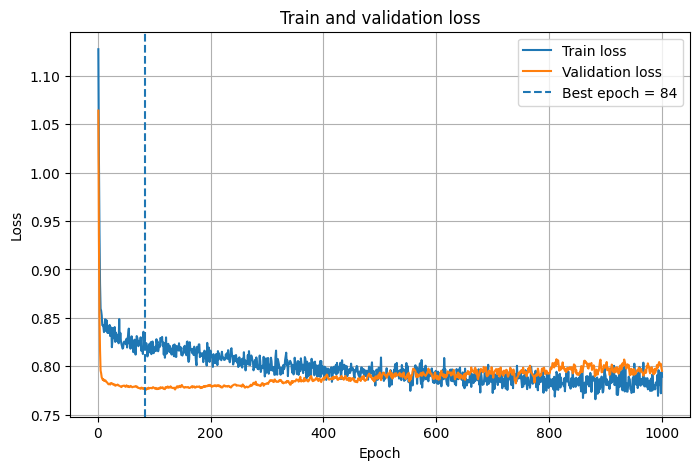

0.5645161290322581

In [11]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [12]:
best_num_epochs = 84

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5645 | Precision: 0.3741 | Recall: 0.4886 | Specificity: 0.7518 | F1: 0.4174

Run 2/10
Accuracy: 0.5565 | Precision: 0.3755 | Recall: 0.4785 | Specificity: 0.7443 | F1: 0.4109

Run 3/10
Accuracy: 0.5565 | Precision: 0.3733 | Recall: 0.4785 | Specificity: 0.7450 | F1: 0.4102

Run 4/10
Accuracy: 0.5565 | Precision: 0.3733 | Recall: 0.4785 | Specificity: 0.7450 | F1: 0.4102

Run 5/10
Accuracy: 0.5645 | Precision: 0.3779 | Recall: 0.4886 | Specificity: 0.7505 | F1: 0.4187

Run 6/10
Accuracy: 0.5645 | Precision: 0.3779 | Recall: 0.4886 | Specificity: 0.7505 | F1: 0.4187

Run 7/10
Accuracy: 0.5645 | Precision: 0.3799 | Recall: 0.4886 | Specificity: 0.7499 | F1: 0.4194

Run 8/10
Accuracy: 0.5565 | Precision: 0.3712 | Recall: 0.4785 | Specificity: 0.7456 | F1: 0.4096

Run 9/10
Accuracy: 0.5685 | Precision: 0.3754 | Recall: 0.4958 | Specificity: 0.7556 | F1: 0.4228

Run 10/10
Accuracy: 0.5685 | Precision: 0.3770 | Recall: 0.4958 | Specificity: 0.7549 | F1: 0.4234

Summary o

In [13]:
save_result(
    experiment_name="Experiment_1-1_FIFA_ranks",
    summary=summary
)


Saved result for Experiment_1-1_FIFA_ranks
File: ../results/experiment_summary_final.csv


In [15]:
save_result_v1(
    experiment_name="Experiment_1-1_FIFA_ranks",
    summary=summary
)


Saved result for Experiment_1-1_FIFA_ranks
File: ../results/experiment_summary_v1.csv
